<a href="https://colab.research.google.com/github/dhushyanthk/AI-Lab/blob/main/EXP25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

class FeedForwardNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights and biases randomly
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def _sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, X):
        # Layer 1 (Hidden Layer)
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self._sigmoid(self.z1)

        # Layer 2 (Output Layer)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self._sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output):
        # Calculate loss derivative
        self.delta2 = (output - y) * self._sigmoid_derivative(output)

        # Calculate gradients for output layer
        self.dW2 = np.dot(self.a1.T, self.delta2)
        self.db2 = np.sum(self.delta2, axis=0, keepdims=True)

        # Calculate hidden layer error
        self.delta1 = np.dot(self.delta2, self.W2.T) * self._sigmoid_derivative(self.a1)

        # Calculate gradients for hidden layer
        self.dW1 = np.dot(X.T, self.delta1)
        self.db1 = np.sum(self.delta1, axis=0, keepdims=True)

    def train(self, X, y, epochs, learning_rate):
        losses = []
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output)

            # Update weights and biases
            self.W1 -= learning_rate * self.dW1
            self.b1 -= learning_rate * self.db1
            self.W2 -= learning_rate * self.dW2
            self.b2 -= learning_rate * self.db2

            # Calculate and store loss
            loss = np.mean(np.square(y - output))
            losses.append(loss)

            if epoch % (epochs // 10) == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
        return losses

    def predict(self, X):
        return self.forward(X)


In [2]:
# Input data for XOR
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Output data for XOR
y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# Initialize the neural network
# Input layer: 2 neurons (for 2 features)
# Hidden layer: 4 neurons (can be tuned)
# Output layer: 1 neuron (for binary output)
model = FeedForwardNeuralNetwork(input_size=2, hidden_size=4, output_size=1)

# Train the network
print("\nStarting training...")
epochs = 10000
learning_rate = 0.8
losses = model.train(X, y, epochs=epochs, learning_rate=learning_rate)
print("Training complete.")



Starting training...
Epoch 0, Loss: 0.2500
Epoch 1000, Loss: 0.2500
Epoch 2000, Loss: 0.2500
Epoch 3000, Loss: 0.2500
Epoch 4000, Loss: 0.2500
Epoch 5000, Loss: 0.2500
Epoch 6000, Loss: 0.2500
Epoch 7000, Loss: 0.2500
Epoch 8000, Loss: 0.2500
Epoch 9000, Loss: 0.2500
Training complete.


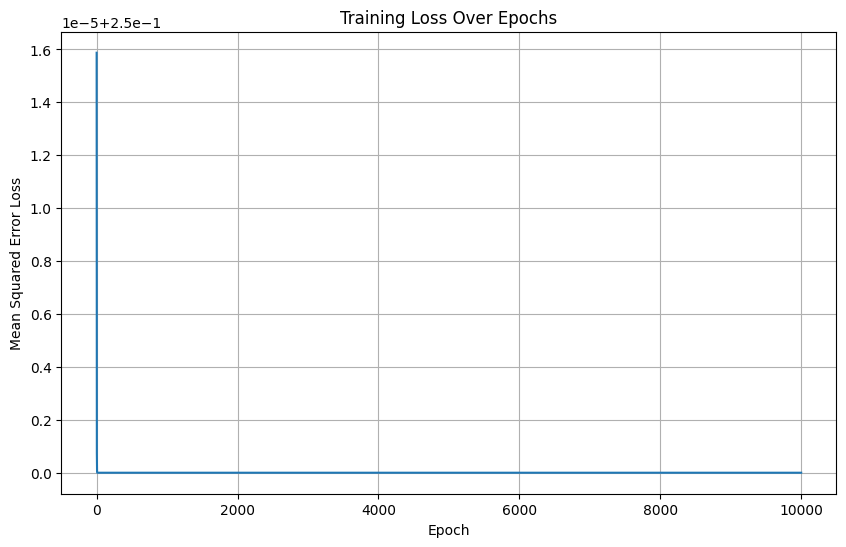

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.grid(True)
plt.show()


In [4]:
print("\nPredictions after training:")
predictions = model.predict(X)
for i in range(len(X)):
    print(f"Input: {X[i]}, Expected: {y[i][0]}, Predicted: {predictions[i][0]:.4f} (Rounded: {np.round(predictions[i][0])})")



Predictions after training:
Input: [0 0], Expected: 0, Predicted: 0.5000 (Rounded: 1.0)
Input: [0 1], Expected: 1, Predicted: 0.5000 (Rounded: 1.0)
Input: [1 0], Expected: 1, Predicted: 0.5000 (Rounded: 0.0)
Input: [1 1], Expected: 0, Predicted: 0.5000 (Rounded: 0.0)
